<a href="https://colab.research.google.com/github/susil-sundar-maharaja/Batch_normalization_tutorial/blob/main/Dropout_early_stopping(tensorflow).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification

print('TensorFlow', tf.__version__)
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow 2.20.0


In [2]:
X, y = make_classification(  # 400 samples, 20 features, 10 informative + 10 noise
    n_samples=400, n_features=20, n_informative=10, n_redundant=0,
    n_clusters_per_class=2, flip_y=0.05, random_state=42
)

In [3]:
X

array([[ 0.20824553,  2.02348199, -2.3510503 , ..., -2.3851137 ,
        -1.11789186, -1.81198934],
       [-3.98257582,  0.7415192 ,  1.68049829, ...,  0.96779447,
        -3.42083795,  1.05004904],
       [-1.91778381, -0.22894108,  2.06137421, ..., -0.26435583,
         0.81552939, -0.6026243 ],
       ...,
       [ 1.38095061,  1.12225031, -1.73772154, ..., -0.56969896,
         0.43601861,  2.63788175],
       [ 0.58425778,  2.14442313,  1.01995354, ..., -0.21578713,
         1.45717035,  1.46978426],
       [-3.71755137,  0.11221818, -0.69124963, ...,  1.59739729,
        -4.27741015, -0.65476978]])

In [4]:
y

array([1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, train_size=250, random_state=42
)

In [6]:
scaler= StandardScaler()
X_train= scaler.fit_transform(X_train)
X_val= scaler.transform(X_val)

print(f'Train: {X_train.shape}, Val: {X_val.shape}')
print(f'Features: {X_train.shape[1]}, Samples per feature: {X_train.shape[0]/X_train.shape[1]:.1f}')

Train: (250, 20), Val: (150, 20)
Features: 20, Samples per feature: 12.5


Over fitting model

In [10]:
def built_overfit_model(input_dim=20):
  model= keras.Sequential([
      layers.Dense(128, activation='relu', input_shape=(input_dim,)),
      layers.Dense(128, activation='relu'),
      layers.Dense(64, activation='relu'),
      layers.Dense(32, activation='relu'),
      layers.Dense(1, activation='sigmoid')
  ])

  model.compile(
      loss= 'binary_crossentropy',
      optimizer= 'adam',
      metrics= ['accuracy']
  )

  return model

model_overfit= built_overfit_model()
model_overfit.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,569 (115.50 KB)

 Trainable params: 29,569 (115.50 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history_overfit= model_overfit.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200, batch_size=16, verbose=0)
print(f'Final — Train Acc: {history_overfit.history["accuracy"][-1]:.3f}, Val Acc: {history_overfit.history["val_accuracy"][-1]:.3f}')

Final — Train Acc: 1.000, Val Acc: 0.800


model with dropout and early stopping

In [12]:
def build_regularize_model(input_dim=20, dropout_rate= 0.4):
  model= keras.Sequential([
      layers.Dense(128, activation='relu', input_shape=(input_dim,)),
      layers.Dropout(dropout_rate),
      layers.Dense(128, activation= 'relu'),
      layers.Dropout(dropout_rate),
      layers.Dense(64, activation='relu'),
      layers.Dropout(dropout_rate),
      layers.Dense(32, activation='relu'),
      layers.Dropout(dropout_rate),
      layers.Dense(1, activation='sigmoid')

  ])
  model.compile(optimizer='adam', loss= 'binary_crossentropy', metrics=['accuracy'])
  return model

model_reg= build_regularize_model()
model_reg.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,569 (115.50 KB)

 Trainable params: 29,569 (115.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stop= callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

history_reg= model_reg.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200, batch_size=16, verbose=0, callbacks=[early_stop])

Epoch 32: early stopping
Restoring model weights from the end of the best epoch: 17.


comparison of training curves

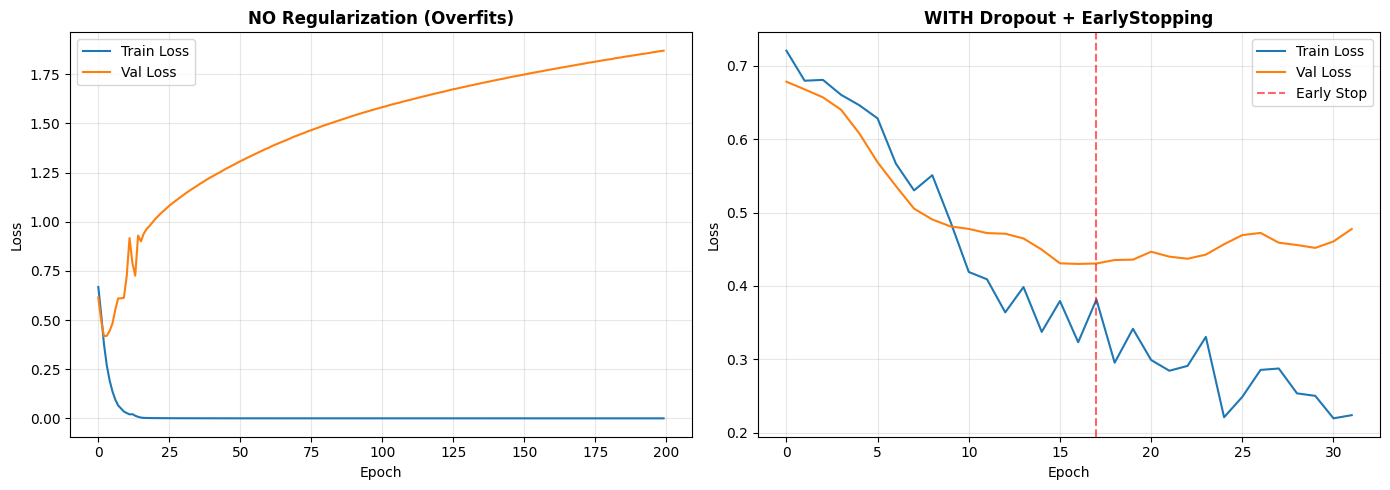

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Overfit model ---
ax = axes[0]
ax.plot(history_overfit.history['loss'], label='Train Loss', linewidth=1.5)
ax.plot(history_overfit.history['val_loss'], label='Val Loss', linewidth=1.5)
ax.set_title('NO Regularization (Overfits)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# --- Regularized model ---
ax = axes[1]
ax.plot(history_reg.history['loss'], label='Train Loss', linewidth=1.5)
ax.plot(history_reg.history['val_loss'], label='Val Loss', linewidth=1.5)
ax.axvline(x=len(history_reg.history['loss'])-15, color='red', linestyle='--', alpha=0.6, label='Early Stop')
ax.set_title('WITH Dropout + EarlyStopping', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

accuracy vs epoch chart comparison

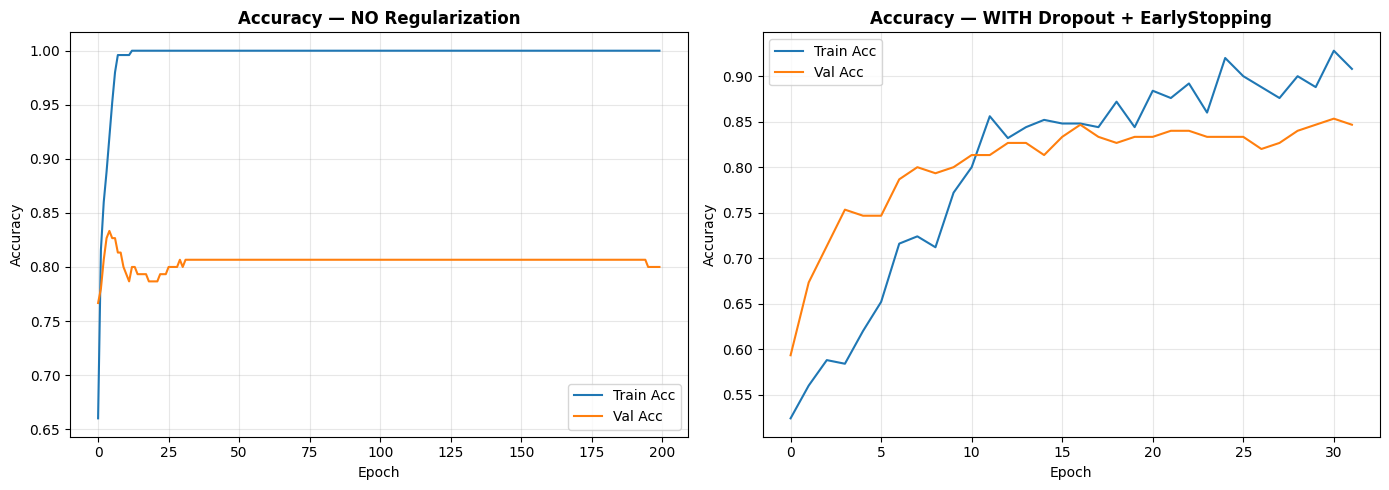

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(history_overfit.history['accuracy'], label='Train Acc', linewidth=1.5)
ax.plot(history_overfit.history['val_accuracy'], label='Val Acc', linewidth=1.5)
ax.set_title('Accuracy — NO Regularization', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(history_reg.history['accuracy'], label='Train Acc', linewidth=1.5)
ax.plot(history_reg.history['val_accuracy'], label='Val Acc', linewidth=1.5)
ax.set_title('Accuracy — WITH Dropout + EarlyStopping', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()